##### Chat bot with Multiple Tools
https://docs.langchain.com/oss/python/integrations/tools
- create chat bot with tool capablities from tavily(web search), Arxiv, wikipedia search and some custom functions

In [ ]:
## arxiv tool
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [6]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [7]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [8]:
## Wikipedia tool
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name


'wikipedia'

In [9]:
wiki.invoke("HUNTER X HUNTER")

'Page: Hunter × Hunter\nSummary: Hunter × Hunter (pronounced "hunter hunter") is a Japanese manga series written and illustrated by Yoshihiro Togashi. It has been serialized in Shueisha\'s shōnen manga magazine Weekly Shōnen Jump since March 1998, although the manga has frequently gone on extended hiatuses since 2006. Its chapters have been collected in 38 tankōbon volumes as of September 2024. The story focuses on a young boy named Gon Freecss who discovers that his father, who left him at a young'

In [10]:
## Tavily
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.environ.get("TAVILY_API_KEY")

In [14]:
"""
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results=5,
    topic="general",
)
"""

from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

C:\Users\dennis joshua j\AppData\Local\Temp\ipykernel_39640\3720625410.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [15]:
tavily.invoke({"query": "What are the IPL standings in 2026"})

[{'title': 'Indian Premier League Standings - 2026 - ESPN',
  'url': 'https://www.espn.com/cricket/standings/series/8048/ipl',
  'content': '| Team | M | W | L | T | N/R | PT | NRR | FOR | Against |\n ---  ---  ---  ---  --- |\n| 1Punjab KingsPBKS | 6 | 5 | 0 | 0 | 1 | 11 | 1.42 | 1050/93.1 | 985/100.0 |\n| 2Royal Challengers BengaluruRCB | 6 | 4 | 2 | 0 | 0 | 8 | 1.171 | 1218/110.5 | 1157/117.5 |\n| 3Rajasthan RoyalsRR | 6 | 4 | 2 | 0 | 0 | 8 | 0.599 | 1004/101.1 | 1032/110.4 |\n| 4Sunrisers HyderabadSRH | 6 | 3 | 3 | 0 | 0 | 6 | 0.566 | 1212/120.0 | 1090/114.2 |\n| 5Delhi CapitalsDC | 5 | 3 | 2 | 0 | 0 | 6 | 0.31 | 886/95.1 | 900/100.0 |\n| 6Gujarat TitansGT | 6 | 3 | 3 | 0 | 0 | 6 | -0.821 | 1022/118.2 | 1127/119.1 |\n| 7Mumbai IndiansMI | 6 | 2 | 4 | 0 | 0 | 4 | 0.067 | 1125/110.1 | 1072/105.4 |\n| 8Chennai Super KingsCSK | 6 | 2 | 4 | 0 | 0 | 4 | -0.78 | 1131/120.0 | 1131/110.5 | [...] | 9Lucknow Super GiantsLSG | 6 | 2 | 4 | 0 | 0 | 4 | -1.173 | 993/119.5 | 1050/111.0 |\n| 10Kolk

In [16]:
tools = [arxiv, wiki, tavily]

In [ ]:
# bind llm with tools
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [18]:
from langchain_core.messages import AIMessage, HumanMessage

tool_call = llm_with_tools.invoke(
    [HumanMessage(content=f"what is the recent IPL news")]
)
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent IPL news. IPL is the Indian Premier League, a cricket tournament. Since they want recent news, I need to check the latest updates. The tools available are arxiv, wikipedia, and tavily_search. Arxiv is for academic papers, which doesn\'t fit. Wikipedia might have general info but not the latest news. Tavily_search is for current events, so that\'s the right choice. I\'ll use tavily_search with the query "recent IPL news" to get the latest information.\n', 'tool_calls': [{'id': 'jjdtg65fq', 'function': {'arguments': '{"query":"recent IPL news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 399, 'total_tokens': 538, 'completion_time': 0.259931154, 'completion_tokens_details': {'reasoning_tokens': 109}, 'prompt_time': 0.0207323, 'prompt_tokens_details': None, 'queue_time': 0.052771283, 'total_time'

In [19]:
# checking the tool response

tool_call.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent IPL news'},
  'id': 'jjdtg65fq',
  'type': 'tool_call'}]

#### Create entire chatbot with the help of langgraph

In [20]:
# create schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

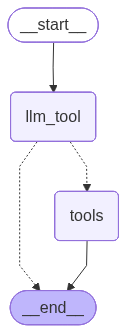

In [ ]:
# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# creating a chatbot node
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # if the latest message from LLM is a toolcall -> tools_condition route to tools
    # if the latest message from LLM is not a toolcall -> tools_condition route to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
# invoke the arxiv tool

messages = graph.invoke({"messages": "1706.03762"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (765awpmcq)
 Call ID: 765awpmcq
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [23]:
# invoke the tavily tool

messages = graph.invoke({"messages": "What are the current IPL standings of 2026"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What are the current IPL standings of 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (mc7gt43zh)
 Call ID: mc7gt43zh
  Args:
    query: current IPL standings 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "IPL 2026 Points Table: Check Latest Standings, NRR & Team Rankings | The Indian Express", "url": "https://indianexpress.com/section/sports/ipl/points-table/", "content": "Currently, Punjab Kings (PBKS) lead the IPL 2026 points table with 11 points and a net run rate of +1.420. Royal Challengers Bengaluru (RCB) are placed at second with 8 points, followed by Rajasthan Royals (RR) in third position with 8 points.\n\nSunrisers Hyderabad (SRH) occupy the fourth spot in the IPL 2026 standings with 6 points, while Delhi Capitals (DC) are placed fif

In [24]:
# invoke the wiki tool

messages = graph.invoke({"messages": "What is machine learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (3e3x4pz3n)
 Call ID: 3e3x4pz3n
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches 
